In [12]:
import ast
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [13]:
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

In [14]:
sns.set_context("paper", font_scale=1.25)
sns.set_palette("Set2")

In [15]:
dimension_map = {
    "Ackley": 30,
    # "Rastrigin": 50,
    # "Schwefel": 500,
    # "Sphere": 500,
    # "Rosenbrock": 100,
    # "Cigar": 50,
}

In [16]:
df = pd.read_csv("../data/experiments_results_final_2.csv")
df["fitness_history"] = df["fitness_history"].apply(ast.literal_eval)
df.head()

,dimension,benchmark,algorithm,best_fitness,best_position,fitness_history,execution_time
0,30,Ackley,PSO,4.622841,"[1.113734483718872, 0.7001715302467346, -0.924...","[19.366552352905273, 19.366552352905273, 19.36...",0.019639
1,30,Ackley,PSO,2.790190,"[0.05833522975444794, 0.3149930238723755, 0.09...","[20.161170959472656, 20.161170959472656, 20.16...",0.016376
2,30,Ackley,PSO,3.946033,"[1.7138893604278564, -0.11006215959787369, -0....","[20.594215393066406, 20.294082641601562, 20.29...",0.015390
3,30,Ackley,PSO,3.115826,"[-1.0325804948806763, -0.07666338980197906, -0...","[19.882823944091797, 19.59520149230957, 19.595...",0.017693
4,30,Ackley,PSO,2.795540,"[-0.055404067039489746, 0.7828329205513, 0.031...","[19.213329315185547, 18.976797103881836, 18.97...",0.015683


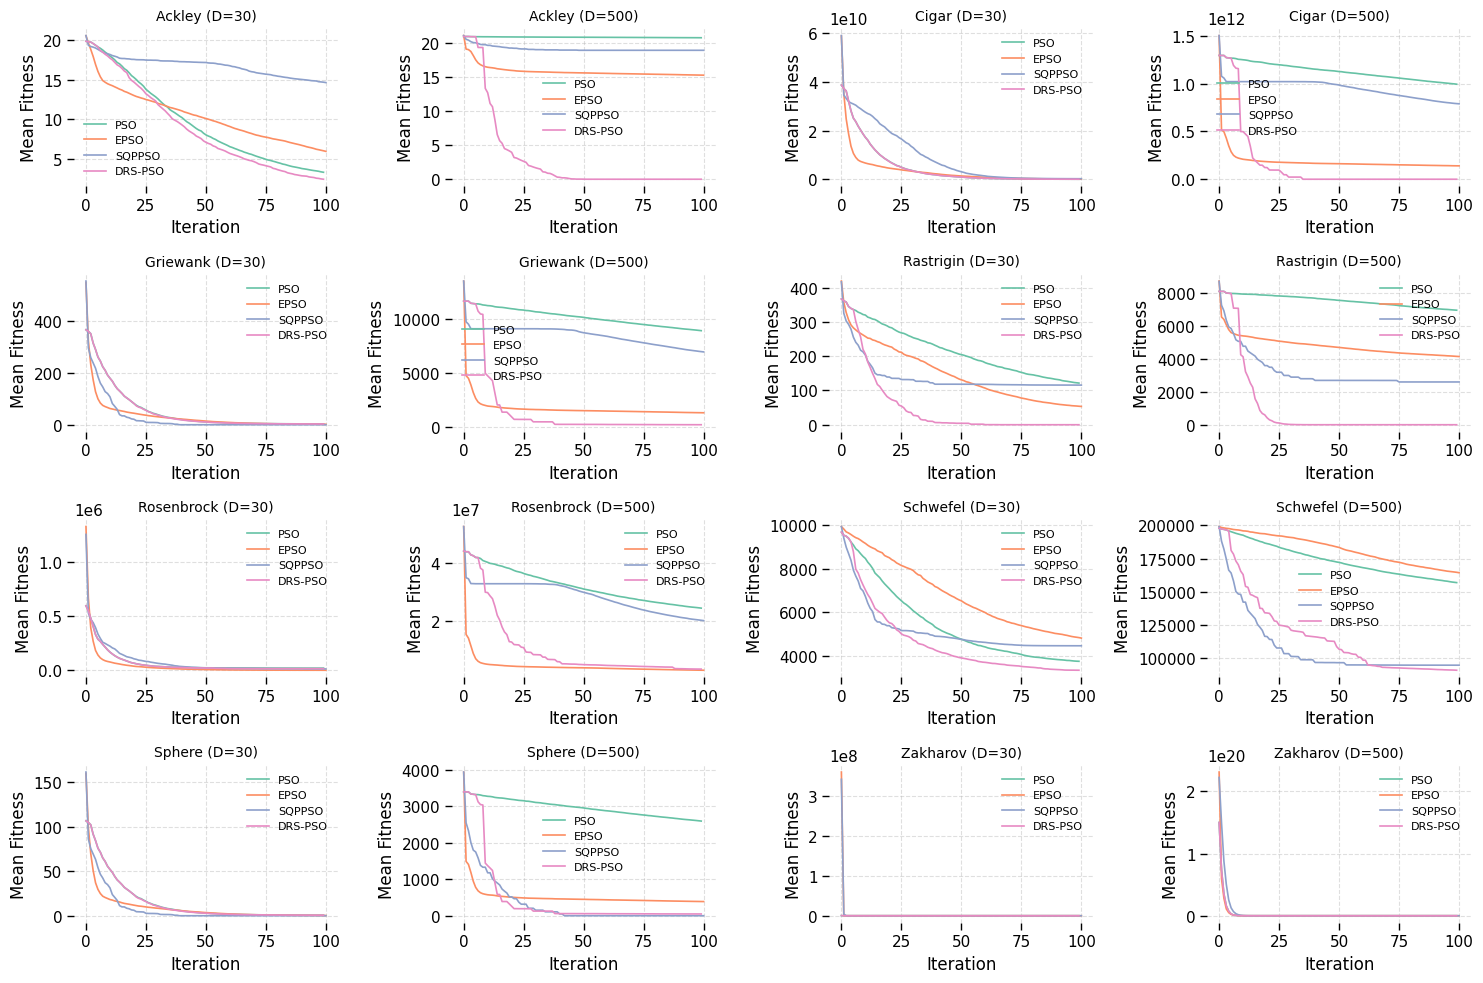

In [17]:
dimensions = [30, 500]

fig, axes = plt.subplots(4, 4, figsize=(15, 10))

benchmarks = df["benchmark"].unique()[:8]  # Assumindo 8 benchmarks para 16 plots

for i, benchmark in enumerate(benchmarks):
    row = i // 2
    col_pair = (i % 2) * 2
    
    # Coluna esquerda do par: dimensão 30
    ax_left = axes[row, col_pair]
    subset_30 = df[(df["dimension"] == 30) & (df["benchmark"] == benchmark)]
    
    for algorithm in subset_30["algorithm"].unique():
        alg_subset = subset_30[subset_30["algorithm"] == algorithm]
        df_fitness = pd.DataFrame(alg_subset["fitness_history"].tolist())
        mean_fitness = df_fitness.mean()
        sns.lineplot(x=range(len(mean_fitness)), y=mean_fitness, label=algorithm, ax=ax_left)
    
    ax_left.set_title(f"{benchmark} (D=30)", fontsize=10)
    ax_left.set_xlabel("Iteration")
    ax_left.set_ylabel("Mean Fitness")
    ax_left.legend(frameon=False, fontsize=8)
    sns.despine(ax=ax_left, left=True, right=True, bottom=True)
    ax_left.grid(linestyle="--", alpha=0.4)
    
    # Coluna direita do par: dimensão 500
    ax_right = axes[row, col_pair + 1]
    subset_500 = df[(df["dimension"] == 500) & (df["benchmark"] == benchmark)]
    
    for algorithm in subset_500["algorithm"].unique():
        alg_subset = subset_500[subset_500["algorithm"] == algorithm]
        df_fitness = pd.DataFrame(alg_subset["fitness_history"].tolist())
        mean_fitness = df_fitness.mean()
        std_fitness = df_fitness.std()
        sns.lineplot(x=range(len(mean_fitness)), y=mean_fitness, label=algorithm, ax=ax_right)
    ax_right.set_title(f"{benchmark} (D=500)", fontsize=10)
    ax_right.set_xlabel("Iteration")
    ax_right.set_ylabel("Mean Fitness")
    ax_right.legend(frameon=False, fontsize=8)
    sns.despine(ax=ax_right, left=True, right=True, bottom=True)
    ax_right.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../results/convergence_plots.pdf", bbox_inches="tight")
plt.show()

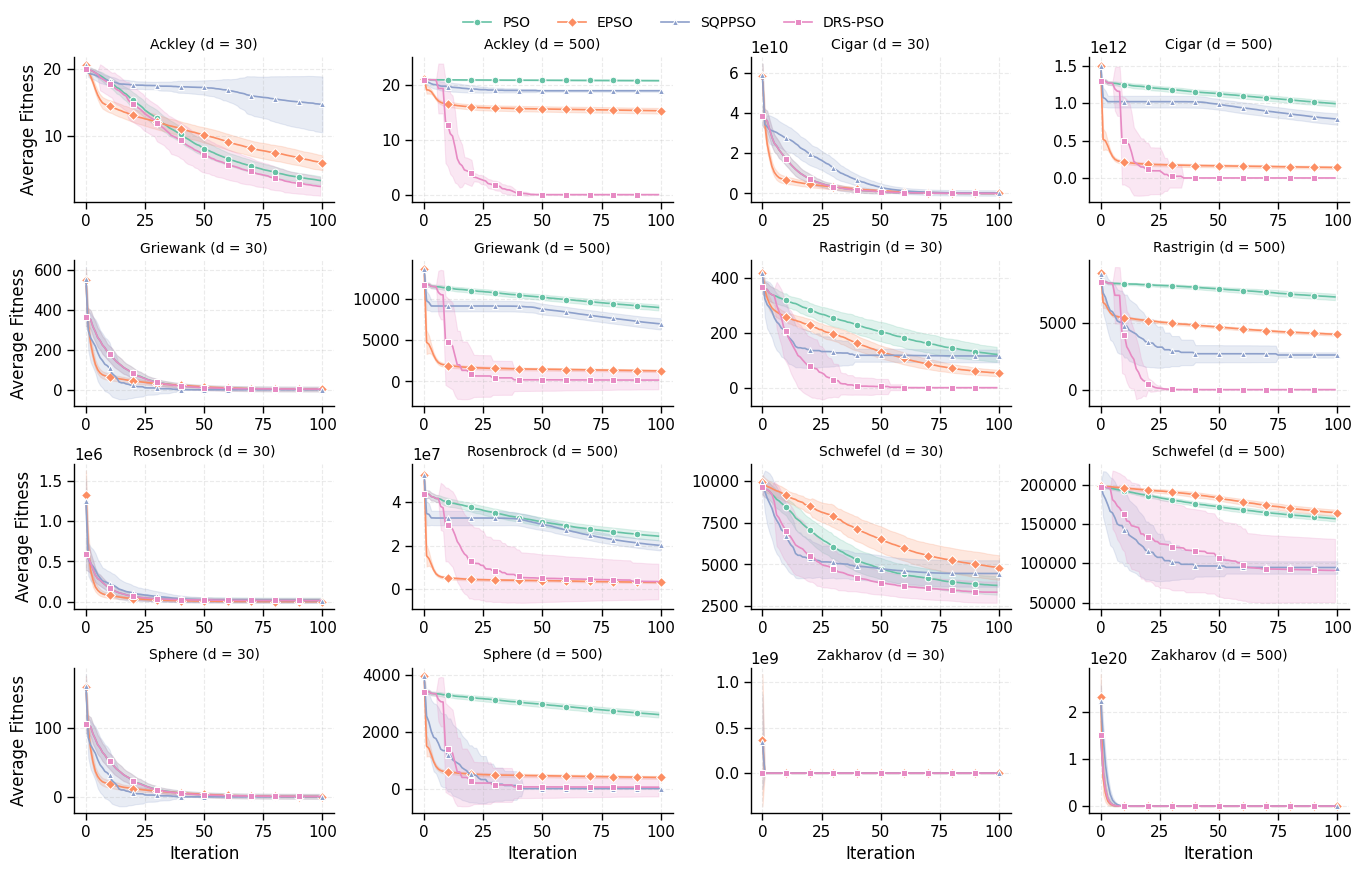

In [42]:
dimensions = [30, 500]
benchmarks = df["benchmark"].unique()[:8]
marker_map = {"PSO": "o", "DRS-PSO": "s", "SQPPSO": "^", "EPSO": "D"}

fig, axes = plt.subplots(4, 4, figsize=(15, 9))

handles, labels = [], []

for i, benchmark in enumerate(benchmarks):
    row = i // 2
    col_pair = (i % 2) * 2

    for j, dim in enumerate(dimensions):
        ax = axes[row, col_pair + j]
        subset = df[(df["dimension"] == dim) & (df["benchmark"] == benchmark)]

        if not subset.empty:
            plot_data = []
            for algorithm in subset["algorithm"].unique():
                alg_subset = subset[subset["algorithm"] == algorithm]
                df_fitness = pd.DataFrame(alg_subset["fitness_history"].tolist())
                df_long = df_fitness.melt(var_name="Iteration", value_name="Fitness")
                df_long["Algorithm"] = algorithm
                plot_data.append(df_long)

            df_plot = pd.concat(plot_data)

            sns.lineplot(
                data=df_plot,
                x="Iteration",
                y="Fitness",
                hue="Algorithm",
                style="Algorithm",
                markers=marker_map,
                dashes=False,
                markevery=10,
                ax=ax,
                errorbar=("sd", 0.95),
                legend=True,
            )

            if not handles:
                handles, labels = ax.get_legend_handles_labels()

            ax.get_legend().remove()

        ax.set_title(f"{benchmark} (d = {dim})", fontsize=10)
        ax.set_xlabel("Iteration" if row == 3 else "")
        ax.set_ylabel("Average Fitness" if col_pair + j == 0 else "")
        ax.grid(visible=True, linestyle="--", alpha=0.25)
        sns.despine(ax=ax)

# Criar a legenda global
if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(labels),
        bbox_to_anchor=(0.5, 0.98),
        frameon=False,
        fontsize=10,
    )
plt.subplots_adjust(top=0.92, bottom=0.08, left=0.1, right=0.95, hspace=0.4, wspace=0.3)

plt.savefig("../results/convergence_plots.pdf")
plt.show()

In [ ]:
# dimensions = [30, 500]

# fig, axes = plt.subplots(4, 4, figsize=(15, 10))
# axes = axes.flatten()

# for ax, benchmark in zip(axes, df["benchmark"].unique()):
#     subset = df[
#         (df["dimension"] == dimension) & (df["benchmark"] == benchmark)
#     ]

#     for algorithm in subset["algorithm"].unique():
#         alg_subset = subset[subset["al˛gorithm"] == algorithm]
#         df_fitness = pd.DataFrame(alg_subset["fitness_history"].tolist())
#         mean_fitness = df_fitness.mean()
#         sns.lineplot(mean_fitness, label=algorithm, ax=ax)

#     ax.set_title(f"Convergence for {benchmark} (D = {dimension})")
#     ax.set_xlabel("Iteration")
#     ax.set_ylabel("Mean Fitness")
#     ax.legend(frameon=False)
#     sns.despine(ax=ax, left=True, right=True, bottom=True)
#     ax.grid(linestyle="--", alpha=0.4)

# plt.tight_layout()
# plt.savefig("../results/convergence_plots.pdf", bbox_inches="tight")
# plt.show()

In [20]:
algorithm_a = "DRS-PSO"
algorithm_b = "PSO"

threshold = 0.05
df_filtered = df[df["algorithm"].isin([algorithm_a, algorithm_b])]

results = []
for benchmark in df_filtered["benchmark"].unique():
    for dimension in df_filtered["dimension"].unique():
        subset = df_filtered[
            (df_filtered["benchmark"] == benchmark)
            & (df_filtered["dimension"] == dimension)
        ]

        fitness_a = subset[subset["algorithm"] == algorithm_a][
            "best_fitness"
        ].to_numpy()
        fitness_b = subset[subset["algorithm"] == algorithm_b][
            "best_fitness"
        ].to_numpy()

        stat, p_value = stats.wilcoxon(fitness_a, fitness_b, alternative="two-sided")

        median_a = np.median(fitness_a)
        median_b = np.median(fitness_b)

        results.append(
            {
                "benchmark": benchmark,
                "dimension": dimension,
                "median_a": np.median(fitness_a),
                "iqr_a": np.percentile(fitness_a, 75) - np.percentile(fitness_a, 25),
                "median_b": np.median(fitness_b),
                "iqr_b": np.percentile(fitness_b, 75) - np.percentile(fitness_b, 25),
                "p-value": p_value,
                "significance": p_value < threshold,
                "-log10(p-value)": -np.log10(p_value),
                "best_algorithm": algorithm_a
                if np.mean(fitness_a) < np.mean(fitness_b)
                else algorithm_b,
            },
        )

df_results = pd.DataFrame(results)
df_results

,benchmark,dimension,median_a,iqr_a,median_b,iqr_b,p-value,significance,-log10(p-value),best_algorithm
0,Ackley,30,2.894279e+00,1.410049e+00,3.297254e+00,7.571034e-01,1.248732e-03,True,2.903531,DRS-PSO
1,Ackley,100,0.000000e+00,0.000000e+00,1.834189e+01,1.488090e+00,1.776357e-15,True,14.750470,DRS-PSO
2,Ackley,300,0.000000e+00,0.000000e+00,2.061748e+01,9.971857e-02,1.776357e-15,True,14.750470,DRS-PSO
3,Ackley,500,0.000000e+00,0.000000e+00,2.083865e+01,8.408070e-02,1.776357e-15,True,14.750470,DRS-PSO
4,Cigar,30,1.810788e+07,1.991085e+07,1.860250e+07,2.052803e+07,1.088094e-01,False,0.963333,DRS-PSO
5,Cigar,100,3.663545e+10,4.644675e+10,4.278543e+10,1.921465e+10,9.815398e-04,True,3.008092,DRS-PSO
6,Cigar,300,1.233158e-23,2.702615e-18,4.708684e+11,3.425574e+10,1.631010e-09,True,8.787543,DRS-PSO
7,Cigar,500,2.558790e-24,4.344517e-20,9.879973e+11,5.500810e+10,1.776357e-15,True,14.750470,DRS-PSO
8,Griewank,30,1.261466e+00,3.023861e-01,1.284538e+00,2.281024e-01,1.171869e-02,True,1.931121,DRS-PSO
9,Griewank,100,3.745746e+02,1.568865e+02,4.063420e+02,1.375775e+02,1.796048e-02,True,1.745682,DRS-PSO


In [21]:
latex_table = []
latex_table.append(r"\begin{table*}")
latex_table.append(r"\centering")
latex_table.append(r"\caption{Results}")
latex_table.append(r"\label{tab:results}")

benchmarks = df["benchmark"].unique()
n_cols = len(benchmarks) + 1

latex_table.append(r"\begin{tabular}{l" + "c" * len(benchmarks) + "}")
latex_table.append(r"\toprule")

header = "Algorithm & " + " & ".join(benchmarks) + r" \\"
latex_table.append(header)

algorithm_a = "DRS-PSO"

for dimension in df["dimension"].unique():
    latex_table.append(
        r"\midrule"
        rf"\multicolumn{{9}}{{c}}{{ $D = {dimension}$ }}"
        r"\\ \midrule",
    )
    for algorithm in df["algorithm"].unique():
        row_data = [algorithm]

        for benchmark in benchmarks:
            subset = df[df["algorithm"] == algorithm]
            alg_subset = subset[
                (subset["benchmark"] == benchmark) & (subset["dimension"] == dimension)
            ]["best_fitness"].to_numpy()

            medians = {}

            for algorithm_2 in df["algorithm"].unique():
                subset_2 = df[df["algorithm"] == algorithm_2]
                alg_subset_2 = subset_2[
                    (subset_2["benchmark"] == benchmark)
                    & (subset_2["dimension"] == dimension)
                ]["best_fitness"].to_numpy()
                medians[algorithm_2] = np.median(alg_subset_2)

            print(medians)

            fitness_a = df[
                (df["algorithm"] == algorithm_a)
                & (df["benchmark"] == benchmark)
                & (df["dimension"] == dimension)
            ]["best_fitness"].to_numpy()

            if algorithm != algorithm_a:
                stat, p_value = stats.wilcoxon(
                    fitness_a, alg_subset, alternative="two-sided",
                )

            if len(alg_subset) > 0:
                median = np.median(alg_subset)

                print(medians)

                text = f"{median:.2e}"

                if algorithm != algorithm_a and p_value < threshold:
                    text = f"\\underline{{{text}}}"
                if median == min(medians.values()):
                    row_data.append(f"\\textbf{{{text}}}")
                else:
                    row_data.append(f"{{{text}}}")
            else:
                row_data.append("-")

        latex_table.append(" & ".join(row_data) + r" \\")

latex_table.append(r"\bottomrule")
latex_table.append(r"\end{tabular}")
latex_table.append(r"\end{table*}")

latex_output = "\n".join(latex_table)
print(latex_output)

with Path.open("../results/results_table.tex", "w") as f:
    f.write(latex_output)

{'PSO': np.float64(3.2972536087036133), 'EPSO': np.float64(5.801291893240121), 'SQPPSO': np.float64(16.561947134659796), 'DRS-PSO': np.float64(2.8942794799804688)}
{'PSO': np.float64(3.2972536087036133), 'EPSO': np.float64(5.801291893240121), 'SQPPSO': np.float64(16.561947134659796), 'DRS-PSO': np.float64(2.8942794799804688)}
{'PSO': np.float64(18602504.0), 'EPSO': np.float64(62527538.00485412), 'SQPPSO': np.float64(17318910.29300513), 'DRS-PSO': np.float64(18107881.0)}
{'PSO': np.float64(18602504.0), 'EPSO': np.float64(62527538.00485412), 'SQPPSO': np.float64(17318910.29300513), 'DRS-PSO': np.float64(18107881.0)}
{'PSO': np.float64(1.2845383286476135), 'EPSO': np.float64(1.742649048798715), 'SQPPSO': np.float64(1.427347573468296e-09), 'DRS-PSO': np.float64(1.2614655494689941)}
{'PSO': np.float64(1.2845383286476135), 'EPSO': np.float64(1.742649048798715), 'SQPPSO': np.float64(1.427347573468296e-09), 'DRS-PSO': np.float64(1.2614655494689941)}
{'PSO': np.float64(119.14382934570312), 'EPS

In [22]:
rows = []
for dimension in df["dimension"].unique():
    for algorithm in df["algorithm"].unique():
        row = {}
        row["Algorithm"] = f"{algorithm} ({dimension})"
        for benchmark in df["benchmark"].unique():
                subset = df[df["algorithm"] == algorithm]
                alg_subset = subset[
                    (subset["benchmark"] == benchmark) & (subset["dimension"] == dimension)
                ]["best_fitness"].to_numpy()
                median = np.median(alg_subset)
                row[f"{benchmark}"] = f"{median:.4f}"

        rows.append(row)


results_df = pd.DataFrame(rows)
results_df

,Algorithm,Ackley,Cigar,Griewank,Rastrigin,Rosenbrock,Schwefel,Sphere,Zakharov
0,PSO (30),3.2973,18602504.0000,1.2845,119.1438,705.8909,3824.9849,0.0829,287.4912
1,EPSO (30),5.8013,62527538.0049,1.7426,54.5262,463.6384,4884.8156,0.1862,210.7099
2,SQPPSO (30),16.5619,17318910.2930,0.0000,112.4300,53.0971,4527.4370,0.0000,0.0000
3,DRS-PSO (30),2.8943,18107881.0000,1.2615,0.0000,256.2447,3315.4644,0.0762,0.0008
4,PSO (100),18.3419,42785431552.0000,406.3420,937.6695,672956.1875,20970.6318,118.0644,3085.4114
5,EPSO (100),12.5777,8753122895.2148,82.4850,467.4349,96001.2915,23468.3070,25.1706,2540.9571
6,SQPPSO (100),18.4898,34894381034.2655,0.0000,459.6691,511079.5290,17969.9375,0.0000,0.0000
7,DRS-PSO (100),0.0000,36635453440.0000,374.5746,0.0000,618298.9375,13102.0820,108.8117,0.0003
8,PSO (300),20.6175,470868410368.0000,4278.3091,3841.6180,9312598.5000,85891.3320,1245.8568,12472.4785
9,EPSO (300),14.7426,69341923593.5464,607.8137,2190.0091,1318304.1768,90639.7214,187.3668,15329.8163


In [23]:
df_results

,benchmark,dimension,median_a,iqr_a,median_b,iqr_b,p-value,significance,-log10(p-value),best_algorithm
0,Ackley,30,2.894279e+00,1.410049e+00,3.297254e+00,7.571034e-01,1.248732e-03,True,2.903531,DRS-PSO
1,Ackley,100,0.000000e+00,0.000000e+00,1.834189e+01,1.488090e+00,1.776357e-15,True,14.750470,DRS-PSO
2,Ackley,300,0.000000e+00,0.000000e+00,2.061748e+01,9.971857e-02,1.776357e-15,True,14.750470,DRS-PSO
3,Ackley,500,0.000000e+00,0.000000e+00,2.083865e+01,8.408070e-02,1.776357e-15,True,14.750470,DRS-PSO
4,Cigar,30,1.810788e+07,1.991085e+07,1.860250e+07,2.052803e+07,1.088094e-01,False,0.963333,DRS-PSO
5,Cigar,100,3.663545e+10,4.644675e+10,4.278543e+10,1.921465e+10,9.815398e-04,True,3.008092,DRS-PSO
6,Cigar,300,1.233158e-23,2.702615e-18,4.708684e+11,3.425574e+10,1.631010e-09,True,8.787543,DRS-PSO
7,Cigar,500,2.558790e-24,4.344517e-20,9.879973e+11,5.500810e+10,1.776357e-15,True,14.750470,DRS-PSO
8,Griewank,30,1.261466e+00,3.023861e-01,1.284538e+00,2.281024e-01,1.171869e-02,True,1.931121,DRS-PSO
9,Griewank,100,3.745746e+02,1.568865e+02,4.063420e+02,1.375775e+02,1.796048e-02,True,1.745682,DRS-PSO


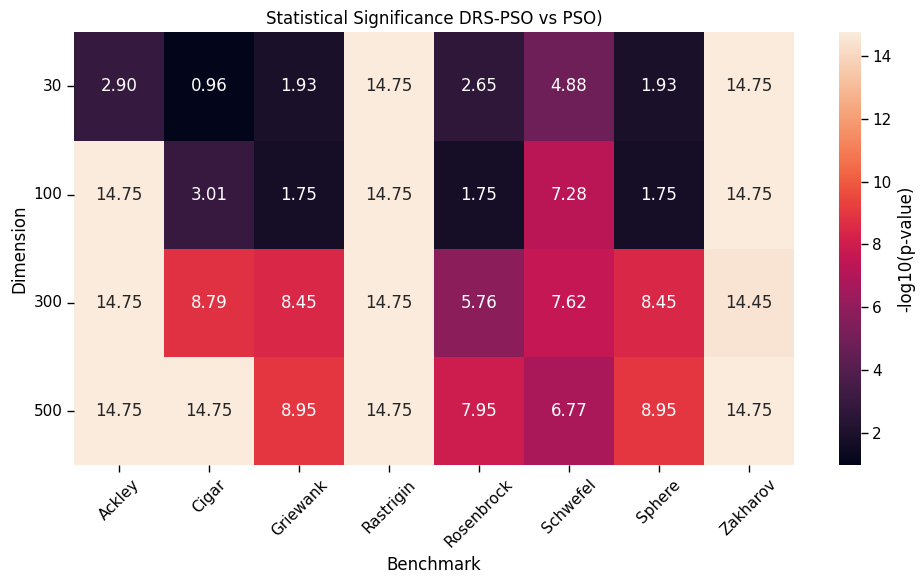

In [24]:
heatmap = df_results.pivot_table("-log10(p-value)", "dimension", "benchmark")
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap, annot=True, fmt=".2f", cbar_kws={"label": "-log10(p-value)"})
plt.title("Statistical Significance DRS-PSO vs PSO)")
plt.xlabel("Benchmark")
plt.ylabel("Dimension")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/significance_heatmap.pdf", bbox_inches="tight")
plt.show()

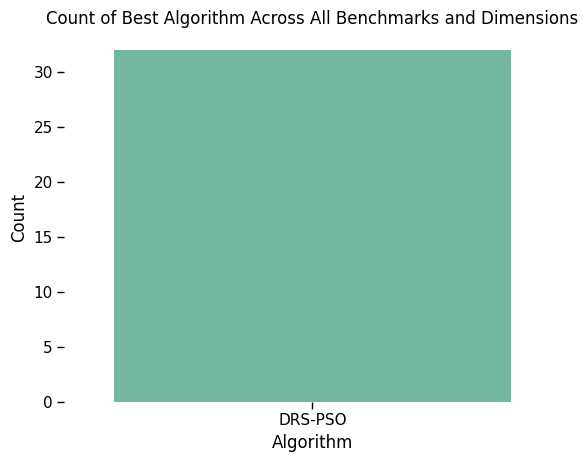

In [25]:
df_count = df_results["best_algorithm"].value_counts().reset_index()
sns.barplot(data=df_count, x="best_algorithm", y="count", hue="best_algorithm")
plt.title("Count of Best Algorithm Across All Benchmarks and Dimensions")
plt.xlabel("Algorithm")
plt.ylabel("Count")
sns.despine(left=True, bottom=True)
plt.savefig("../results/best_algorithm_count.pdf", bbox_inches="tight")
plt.show()

In [26]:
# fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
# axes = axes.flatten()

# for ax, dimension in zip(axes, df["dimension"].unique()):
#     mean = (
#         df[df["dimension"] == dimension]
#         .groupby(["benchmark", "algorithm"])["execution_time"]
#         .mean()
#     )

#     sns.barplot(
#         x=mean.values,
#         y=mean.index.get_level_values("benchmark"),
#         hue=mean.index.get_level_values("algorithm"),
#         orient="h",
#         ax=ax,
#     )
#     ax.set_title(f"Execution Time by Algorithm and Benchmark (Dimension: {dimension})")
#     ax.set_xlabel("Benchmark")
#     ax.set_ylabel("Mean Execution Time (s)")
#     ax.legend(title="Algorithm")
#     ax.tick_params(axis="x", rotation=45)

# plt.tight_layout()
# plt.show()